In [1]:
import pandas as pd
from net2rank.utils import H5Loader, process_train_file
import os
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from itertools import combinations
import numpy as np
import gzip
from tqdm import tqdm

In [6]:
def parse_string_network(string_file: str):
    """
    Parse STRING network file to extract degrees and edges.
    
    Args:
        string_file: Path to gzipped STRING file
    
    Returns:
        Tuple of (weighted_degrees, degrees, edges)
    """
    weighted_degrees = {}
    degrees = {}
    edges = []
    
    with gzip.open(string_file, "rb") as f:
        for i, line in enumerate(tqdm(f.readlines(), desc="Parsing STRING")):
            parts = line.decode("utf-8").split(' ')
            
            if parts[0] == 'protein1':  # Skip header
                continue
            
            protein1, protein2 = parts[0], parts[1]
            weight = int(parts[-1]) / 1000
            
            # Update degrees for both proteins
            for protein in [protein1, protein2]:
                if protein not in weighted_degrees:
                    weighted_degrees[protein] = weight
                    degrees[protein] = 1
                else:
                    weighted_degrees[protein] += weight
                    degrees[protein] += 1
            
            edges.append([protein1, protein2])
    
    return weighted_degrees, degrees, edges


weighted_degrees, degrees, edges = parse_string_network('data/9606.protein.links.detailed.v12.0.txt.gz')

df_degrees = pd.DataFrame({
    'protein': list(degrees.keys()),
    'degree': list(degrees.values()),  
    'weighted_degree': list(weighted_degrees.values())
})
df_degrees['degree'] = df_degrees['degree'] /2
df_degrees['weighted_degree'] = df_degrees['weighted_degree'] /2
df_degrees['log_weighted_degree'] = np.log10(df_degrees['weighted_degree'] + 1)

Parsing STRING: 100%|██████████| 13715405/13715405 [00:56<00:00, 240885.47it/s]


In [7]:
embedding_file = 'data/9606.node2vec64.h5'
human_embeddings = H5Loader(embedding_file)
protein_space = human_embeddings.proteins

In [8]:
def get_pos_degrees(train_file, file_type, protein_space,pos_size):
    df_train = process_train_file(train_file, file_type, protein_space,pos_size,)
    pos_proteins = df_train[df_train.iloc[:,1] == 1].iloc[:,0].tolist()
    disease_name = os.path.basename(train_file).split('.')[0]
    scores = df_degrees[df_degrees['protein'].isin(pos_proteins)].iloc[:,3].values
    return disease_name, scores

In [9]:
pos_stats = dict()

train_file = 'data/train/atopic_dermatitis.integrated.tsv'
file_type = 'pvalue'
pos_size = 1000
disease_name, scores = get_pos_degrees(train_file, file_type, protein_space,pos_size)
pos_stats[disease_name] = scores

train_file = 'data/train/ulcerative_colitis.integrated.tsv'
file_type = 'pvalue'
pos_size = 1300
disease_name, scores = get_pos_degrees(train_file, file_type, protein_space,pos_size)
pos_stats[disease_name] = scores

train_file = 'data/train/focal_epilepsy.rnaseq.kjaer_guelfi_consensus.tsv'
file_type = 'list' 
pos_size = None
disease_name, scores = get_pos_degrees(train_file, file_type, protein_space,pos_size)
pos_stats[disease_name] = scores

train_file = 'data/train/colorectal_adenocarcinoma.mutations.intogen.tsv'
file_type = 'list' 
pos_size = None
disease_name, scores = get_pos_degrees(train_file, file_type, protein_space,pos_size)
pos_stats[disease_name] = scores

train_file = 'data/train/melanoma.mutations.intogen.tsv'
file_type = 'list' 
pos_size = None
disease_name, scores = get_pos_degrees(train_file, file_type, protein_space,pos_size)
pos_stats[disease_name] = scores

train_file = 'data/train/diffuse_large_b-cell_lymphoma.mutations.intogen.tsv'
file_type = 'list' 
pos_size = None
disease_name, scores = get_pos_degrees(train_file, file_type, protein_space,pos_size)
pos_stats[disease_name] = scores

train_file = 'data/train/aortic_aneurysm.olink.tsv'
file_type = 'label' 
pos_size = None
disease_name, scores = get_pos_degrees(train_file, file_type, protein_space,pos_size)
pos_stats[disease_name] = scores


Median of all proteins: 2.14


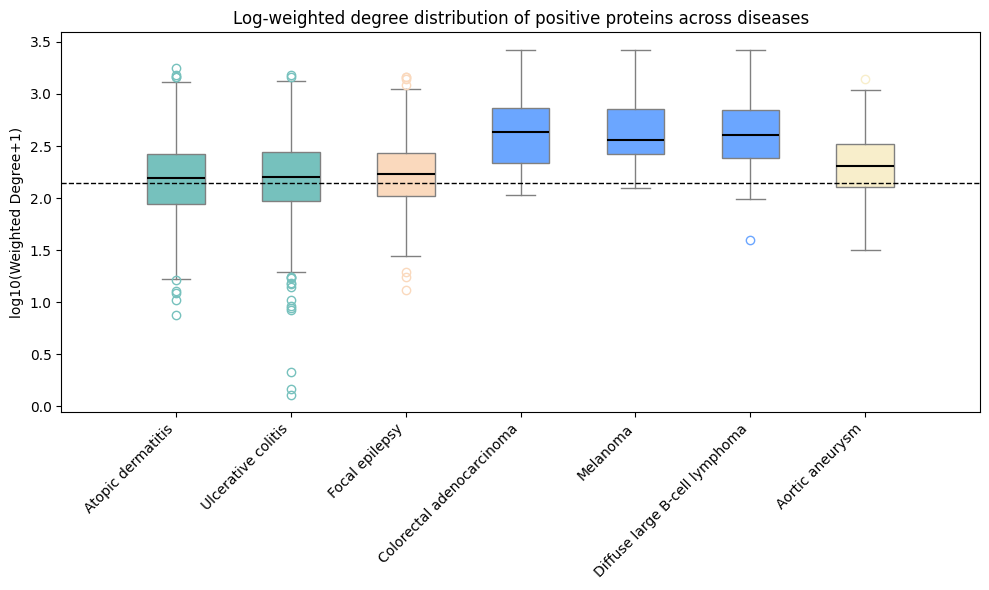

In [11]:
all_median = np.median(df_degrees.iloc[:,3].values)
print(f'Median of all proteins: {all_median:.2f}')
colors = ['#76c1bd','#fad9bd','#6ba6ff','#f8eecb']
disease2color = {
    'atopic_dermatitis': colors[0],
    'ulcerative_colitis': colors[0],
    'focal_epilepsy': colors[1],
    'colorectal_adenocarcinoma': colors[2],
    'melanoma': colors[2],
    'diffuse_large_b-cell_lymphoma': colors[2],
    'aortic_aneurysm': colors[3]
}
plt.figure(figsize=(10,6))
xlabels = []
bp2 = plt.boxplot([list(v) for k,v in pos_stats.items()], patch_artist=True)
for i,disease in enumerate(pos_stats):
    display_disease = disease.replace('_', ' ').capitalize()
    if 'b-cell' in display_disease:
        display_disease = display_disease.replace('b-cell', 'B-cell')
    xlabels.append(display_disease)
    c = disease2color.get(disease, '#cccccc')
    bp2['boxes'][i].set_facecolor(c)
    bp2['boxes'][i].set_edgecolor('grey')
    bp2['medians'][i].set_color('black')
    bp2['medians'][i].set_linewidth(1.5)
    for key in ['whiskers', 'caps']:
        bp2[key][2*i].set_color('grey')
        bp2[key][2*i+1].set_color('grey')
    bp2['fliers'][i].set_markeredgecolor(c)
    
plt.hlines(all_median,0,len(pos_stats)+1,colors='k', linestyles='dashed', linewidth=1)
plt.xlim(0, len(pos_stats)+1)
plt.xticks(range(1, len(pos_stats)+1),xlabels, rotation=45, ha='right')
plt.ylabel('log10(Weighted Degree+1)')
plt.title('Log-weighted degree distribution of positive proteins across diseases')
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('results/supp_figures/fig.s2.positive_protein_degree_distribution.png', dpi=300)
plt.show()

In [12]:
df_compare = list()
for disease1, disease2 in combinations(pos_stats.keys(), 2):
    scores1 = pos_stats[disease1]
    scores2 = pos_stats[disease2]
    stat, p_value = mannwhitneyu(scores1, scores2, alternative='two-sided')
    p_value = round(p_value, 4)
    # print(f"Comparison: {disease1} vs {disease2} - P-value: {p_value} U-statistic: {stat}")
    disease1_display = disease1.replace('_', ' ').capitalize()
    disease2_display = disease2.replace('_', ' ').capitalize()
    if p_value == 0:
        p_value = '<1e-300'
    df_compare.append({'Disease1': disease1_display, 'Disease2': disease2_display, 
                                    'P-value': p_value, 'U-statistic': stat})
df_compare = pd.DataFrame(df_compare)
df_compare.to_csv('results/table.s7.degree_comparison_results.csv', index=False)

In [2]:
### module analysis
df_results = list()

diseases = ['atopic_dermatitis', 'ulcerative_colitis', 'focal_epilepsy', 'colorectal_adenocarcinoma',
            'melanoma', 'diffuse_large_b-cell_lymphoma', 'aortic_aneurysm']
for disease in diseases:
    file = f'results/disease_modules/{disease}.csv'

    df_module = pd.read_csv(file)
    disease_name = os.path.basename(file).split('.')[0]
    display_disease = disease_name.replace('_', ' ').capitalize()
    if 'b-cell' in display_disease:
        display_disease = display_disease.replace('b-cell', 'B-cell')
    df_module = df_module[df_module['# genes']>3]
    df_module = df_module[df_module['category']=='GO Biological Process']
    df_module = df_module[(df_module['p-value']<0.05) & (df_module['FDR value']<0.05)]
    n_modules = df_module['term name'].nunique()
    mean_module_size = round(df_module['# genes'].mean(), 2)
    
    df_pred = pd.read_csv(os.path.join('results/test_results', f'{disease_name}/{disease_name}_fpr_0.05_prediction_results.tsv'), sep='\t')
    n_pred = df_pred.shape[0]
    
    df_results.append({'Disease': display_disease, 'Total Network Size (Nodes)':n_pred,
                        'Number of Modules (≥3 nodes)': n_modules, 'Mean Module Size': mean_module_size,
                        })
df_results = pd.DataFrame(df_results)
df_results.to_csv('results/table.s8.function_modules_summary.csv')
df_results

,Disease,Total Network Size (Nodes),Number of Modules (≥3 nodes),Mean Module Size
0,Atopic dermatitis,1717,157,37.89
1,Ulcerative colitis,2647,204,29.05
2,Focal epilepsy,1329,70,10.56
3,Colorectal adenocarcinoma,2213,158,22.39
4,Melanoma,3320,33,26.85
5,Diffuse large B-cell lymphoma,3183,18,20.44
6,Aortic aneurysm,996,31,11.90
